# **Multiple Linear Regression – Multi-Channel Marketing Analysis**

In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, rand_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
import statsmodels.api as sm

In [2]:
# Loading dataset
df = pd.read_csv('marketing_sales_data.csv')
# Viewing first 5 rows
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [3]:
df.columns

Index(['TV', 'Radio', 'Social Media', 'Influencer', 'Sales'], dtype='object')

## Data Exploration and Cleaning

In [4]:
# Number of rows and columns
df.shape

(572, 5)

In [5]:
# Information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB


In [6]:
# Checking for duplicate records
df.duplicated().sum()

np.int64(0)

In [7]:
# Checking for missing values
df.isna().sum()

TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

In [8]:
# Summary statistics of numeric variables
df.describe()

,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


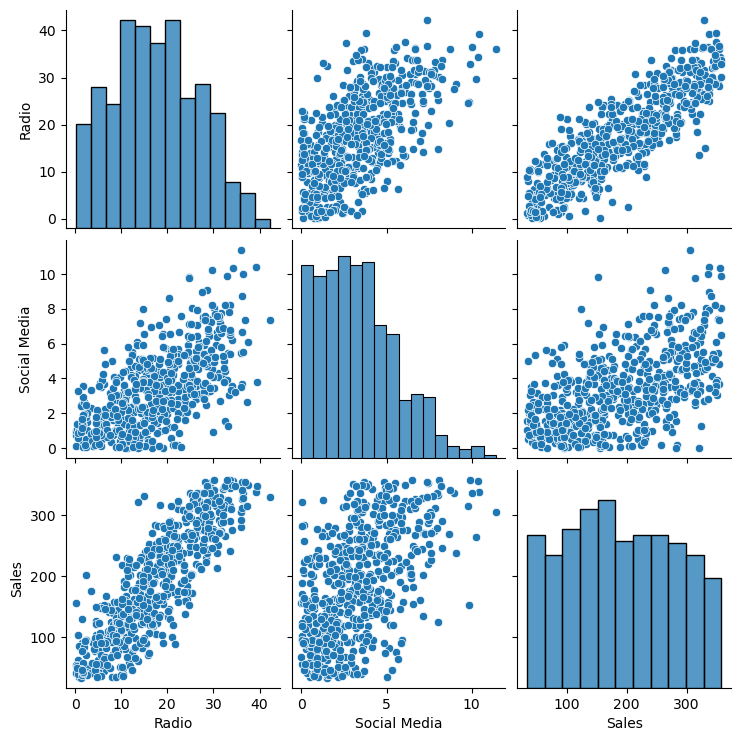

In [9]:
# Checking the relationship between variables in the data
sns.pairplot(df)
plt.show()

### **Data Preprocessing and feature scaling**

In [10]:
# Encoding target variable
label_enc = LabelEncoder()
y = label_enc.fit_transform(df['Sales'])

# Encoding independent variables
num_feat = df[['Radio','Social Media']]
cat_feat = df[['TV','Influencer']]

ord_enc = OrdinalEncoder()
std_scaler = StandardScaler()

cat_feat_encoded = pd.DataFrame(ord_enc.fit_transform(cat_feat),columns=ord_enc.get_feature_names_out(cat_feat.columns))
num_feat_encoded = pd.DataFrame(std_scaler.fit_transform(num_feat),columns=num_feat.columns)

x = pd.concat([cat_feat_encoded,num_feat_encoded],axis=1)

In [11]:
x.columns

Index(['TV', 'Influencer', 'Radio', 'Social Media'], dtype='object')

                    TV     Radio  Social Media
TV            1.000000 -0.395841     -0.262081
Radio        -0.395841  1.000000      0.629941
Social Media -0.262081  0.629941      1.000000


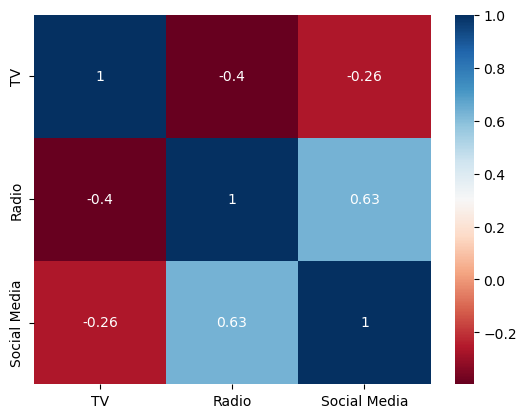

In [12]:
# Assessing multicollinearity with correlation matrix
var = x[['TV','Radio','Social Media']]
corr = var.corr()
print(corr)
sns.heatmap(corr, annot=True, cmap='RdBu')
plt.show()

## **Building Model with SKLearn**

In [13]:
# Splitting dataset - 80% Train; 20% Test
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
# Fitting dataset into model for training
lin_reg = LinearRegression()
lin_reg.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
lin_reg.intercept_

np.float64(296.35055251925615)

In [16]:
# Predicting and Evaluating on Test dataset
y_pred = lin_reg.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-Squared calue: {r2:.2f}")

Mean Squared Error: 9020.50
Root Mean Squared Error: 94.98
Mean Absolute Error: 78.34
R-Squared calue: 0.66


## **Building Model with Statsmodel**

In [17]:
x_sm = sm.add_constant(x)

ols_model = sm.OLS(y, x_sm).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     398.9
Date:                Fri, 19 Jun 2026   Prob (F-statistic):          3.21e-163
Time:                        23:46:55   Log-Likelihood:                -3349.8
No. Observations:                 572   AIC:                             6710.
Df Residuals:                     567   BIC:                             6731.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          301.3435      8.185     36.819   

### **Interpretation of OLS Results**

The multiple linear regression model explains approximately 73.8% of the variation in Sales using TV level, Radio spend, Social Media spend, and Influencer category.

The adjusted R² value of 0.736 indicates that the model retains strong explanatory power after accounting for the number of predictors included.

The F-test p-value (3.21e-163) results shows that the model results are statistically significant

Radio advertising is the strongest positive driver of sales in the model. A one-unit increase in Radio advertising spend is associated with an estimated 137.10 unit increase in Sales

A surprising finding was that a higher TV advertising category is associated with an estimated decrease of 14.12 units in Sales. This could be because TV categories may not represent actual spending amounts

Influencer type and Social Media spending did not show a statistically significant independent effect on Sales after controlling for other predictors.

### **Final Model Equation**

Sales = 301.34 − 14.12(TV) + 137.10(Radio) − 0.19(SocialMedia) − 0.48(Influencer)

In [18]:
# Getting residuals and fitted values
residuals = ols_model.resid
fitted_values = ols_model.fittedvalues

## **Diagnostic plots**

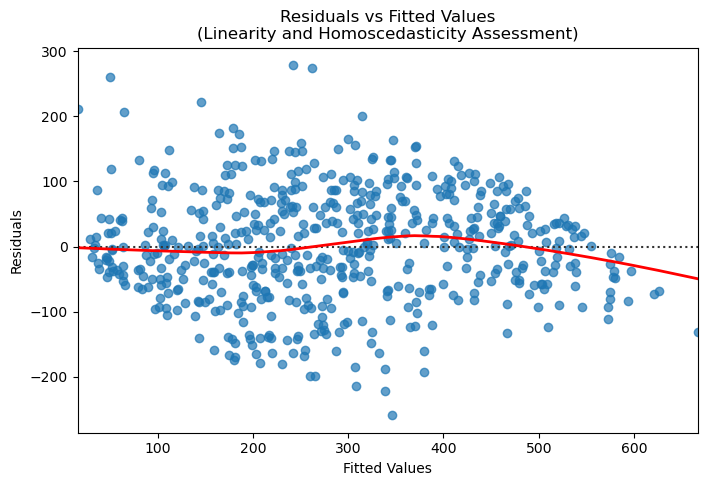

In [19]:
# Linearity & Homoscedasticity check
plt.figure(figsize=(8,5))

sns.residplot(
    x=fitted_values,
    y=residuals,
    lowess=True,
    scatter_kws={'alpha':0.7},
    line_kws={'color':'red','linewidth':2}
)

plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

plt.title('Residuals vs Fitted Values\n(Linearity and Homoscedasticity Assessment)')

plt.show()

The plot above shows that the assumption of homoscedasticity is reasonably satisfied. However, slight variations in residual spread and the presence of several outliers indicate mild heteroscedasticity.

The LOWESS line showed only slight curvature at higher fitted values, indicating minor deviations from perfect linearity.

Nonetheless, both assumptions were met.

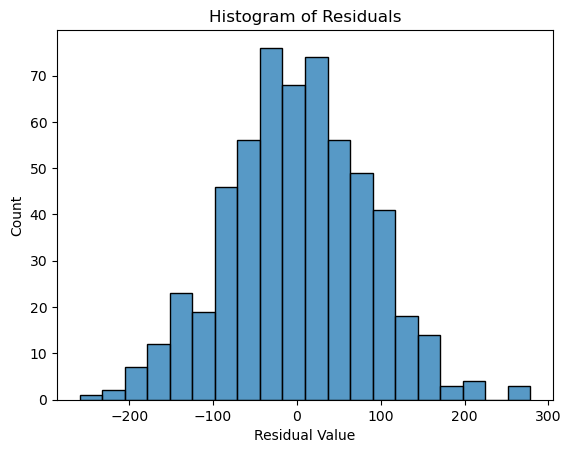

In [20]:
# Checking Normality Assumption
fig = sns.histplot(residuals)
fig.set_xlabel("Residual Value")
fig.set_title("Histogram of Residuals")
plt.show()

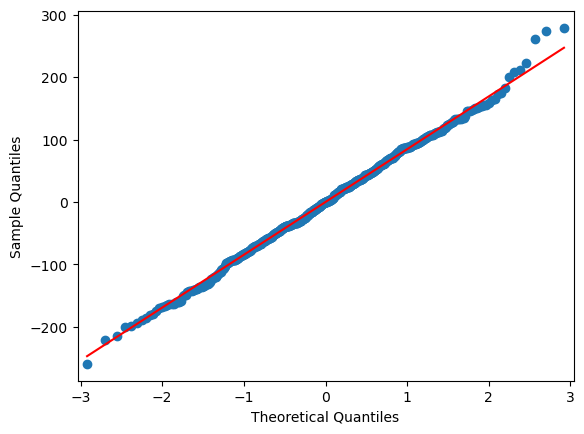

In [21]:
# Q-Q Plot

fig = sm.qqplot(ols_model.resid, line = 's')
plt.show()

Omnibus p = 0.915

Jarque-Bera p = 0.955

The histogram, Q-Q plot, and the values above reveal that the residuals are normally distributed

## **Recommendations**

The regression analysis shows that Radio advertising is the strongest driver of Sales, with a statistically significant positive relationship.

The company should prioritize investment in Radio marketing channels while continuously evaluating the effectiveness of TV and Social Media campaigns. 

Although Social Media and Influencer variables were included in the model, they did not demonstrate significant independent contributions to sales, suggesting that their impact may depend on other factors or require further analysis.